<a href="https://colab.research.google.com/github/ozhao1323/ECON3916-Statistical-and-Machine-Learning/blob/main/Lab%2015/%5BLab_15%5D_Lab%5D_From_Regression_to_Machine_Learning_%E2%80%94_The_Bias_Variance_Tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete ✓')

Setup complete ✓


In [ ]:
n_train = 50
n_test = 200
noise_std = 0.3

def true_function(x):
    return np.sin(2 * np.pi * x)

# Training data
x_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = true_function(x_train) + np.random.normal(0, noise_std, n_train)

# Test data (separate - the model never sees this)
x_test = np.sort(np.random.uniform(0, 1, n_test))
y_test = true_function(x_test) + np.random.normal(0, noise_std, n_test)

x_plot = np.linspace(0, 1, 300)

print(f'Training set: {n_train} observations')
print(f'Test set:     {n_test} observations')
print(f'Noise std:    {noise_std} (sigma^2 = {noise_std**2:.2f})')

Training set: 50 observations
Test set:     200 observations
Noise std:    0.3 (sigma^2 = 0.09)


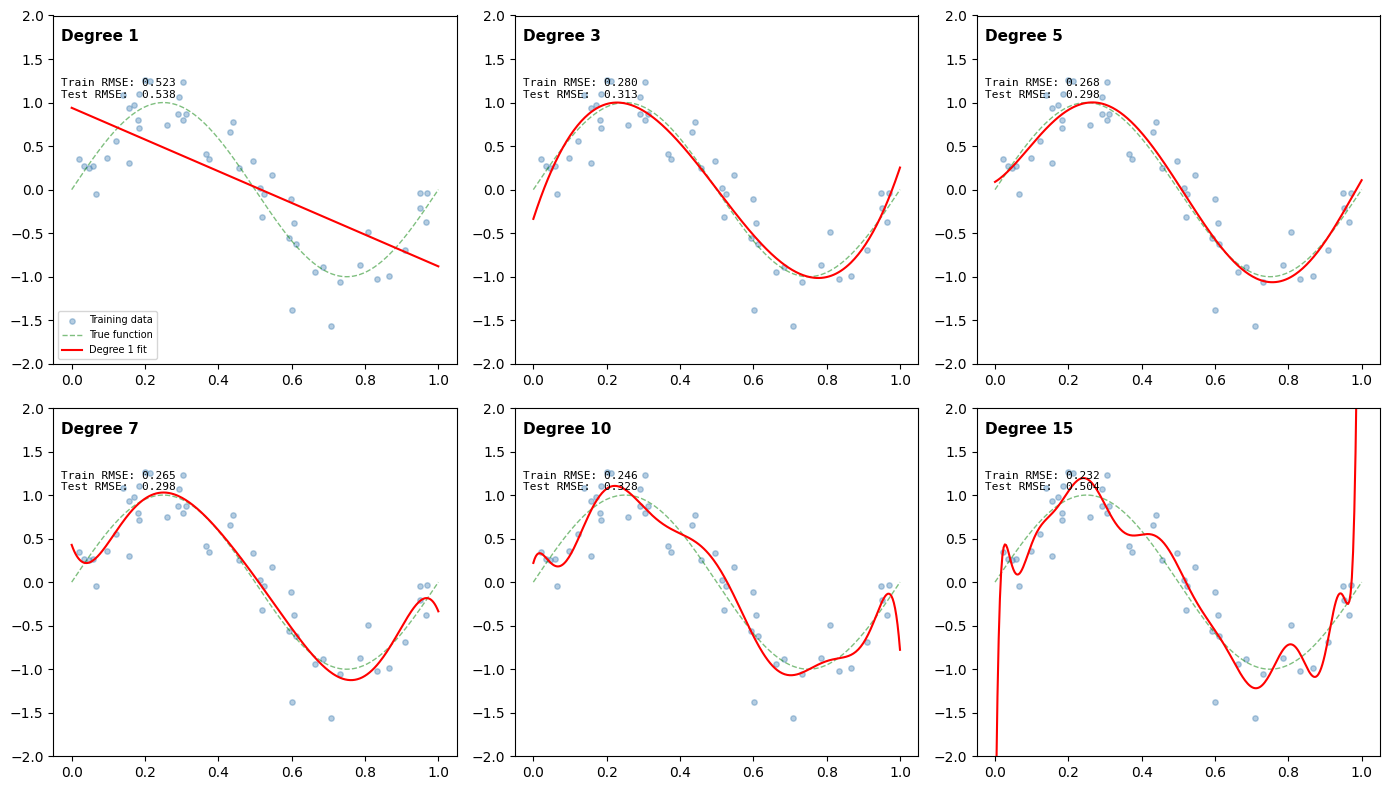

In [ ]:
degrees = [1, 3, 5, 7, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, d in enumerate(degrees):
    ax = axes[idx]
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax.scatter(x_train, y_train, alpha=0.4, s=15, color='steelblue',
               label='Training data')
    ax.plot(x_plot, true_function(x_plot), 'g--', alpha=0.5,
            linewidth=1, label='True function')
    ax.plot(x_plot, y_pred_plot, 'r-', linewidth=1.5,
            label=f'Degree {d} fit')
    ax.set_ylim(-2, 2)
    ax.text(0.02, 0.96, f'Degree {d}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.02, 0.82,
            f'Train RMSE: {train_rmse:.3f}\nTest RMSE:  {test_rmse:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            fontfamily='monospace')
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

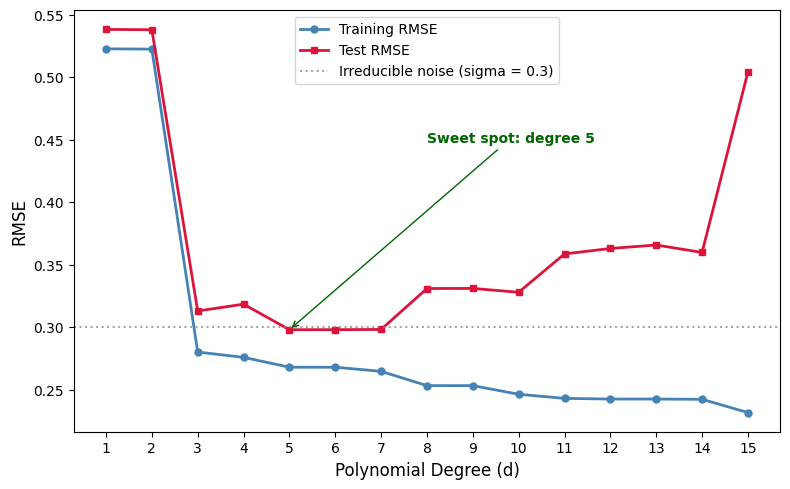

In [ ]:
all_degrees = range(1, 16)
train_errors = []
test_errors = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(all_degrees), train_errors, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Training RMSE')
ax.plot(list(all_degrees), test_errors, 's-', color='crimson',
        linewidth=2, markersize=5, label='Test RMSE')
ax.axhline(y=noise_std, color='gray', linestyle=':', alpha=0.7,
           label=f'Irreducible noise (sigma = {noise_std})')

best_degree = list(all_degrees)[np.argmin(test_errors)]
best_test_rmse = min(test_errors)
ax.annotate(f'Sweet spot: degree {best_degree}',
            xy=(best_degree, best_test_rmse),
            xytext=(best_degree + 3, best_test_rmse + 0.15),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
def manual_kfold_cv(x, y, degree, k=5):
    """
    Perform k-fold cross-validation for polynomial regression.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    y : np.ndarray, shape (n,)
    degree : int
    k : int

    Returns
    -------
    float : Mean CV RMSE
    np.ndarray : Per-fold RMSE values
    """
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_errors = []

    for i in range(k):
        # Create test and train indices for this fold
        test_idx = folds[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(k) if j != i]
        )

        # Split data
        x_fold_train, y_fold_train = x[train_idx], y[train_idx]
        x_fold_test, y_fold_test = x[test_idx], y[test_idx]

        # Fit polynomial model on training fold
        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression()
        )
        model.fit(x_fold_train.reshape(-1, 1), y_fold_train)

        # Predict on test fold and compute RMSE
        y_pred = model.predict(x_fold_test.reshape(-1, 1))
        fold_rmse = np.sqrt(mean_squared_error(
            y_fold_test, y_pred))
        fold_errors.append(fold_rmse)

    fold_errors = np.array(fold_errors)
    return fold_errors.mean(), fold_errors

In [ ]:
from sklearn.model_selection import cross_val_score

model_d3 = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

# cross_val_score returns NEGATIVE MSE (sklearn convention)
cv_scores = cross_val_score(
    model_d3, x_train.reshape(-1, 1), y_train,
    cv=5, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)

print(f'sklearn 5-fold CV RMSE (degree 3): '
      f'{cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')
print(f'Per-fold RMSE: {cv_rmse}')

sklearn 5-fold CV RMSE (degree 3): 0.7226 +/- 0.8230
Per-fold RMSE: [0.33804966 0.22992916 0.24712496 0.43602712 2.36206012]


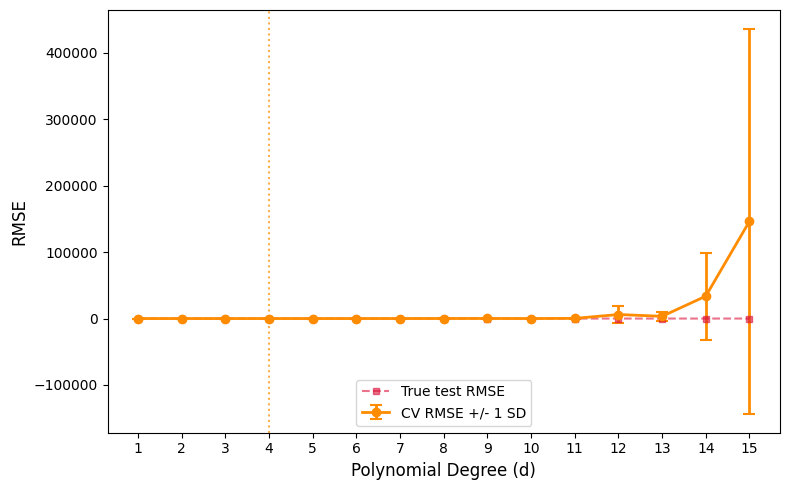

CV-selected degree: 4
True optimal degree: 5


In [ ]:
all_degrees = range(1, 16)
cv_means = []
cv_stds = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    scores = cross_val_score(
        model, x_train.reshape(-1, 1), y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    cv_means.append(rmse_scores.mean())
    cv_stds.append(rmse_scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(list(all_degrees), cv_means, yerr=cv_stds,
            fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=4, capthick=1.5,
            label='CV RMSE +/- 1 SD')
ax.plot(list(all_degrees), test_errors, 's--', color='crimson',
        linewidth=1.5, markersize=4, alpha=0.6,
        label='True test RMSE')

cv_best_degree = list(all_degrees)[np.argmin(cv_means)]
ax.axvline(x=cv_best_degree, color='darkorange', linestyle=':',
           alpha=0.7)

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'CV-selected degree: {cv_best_degree}')
print(f'True optimal degree: {best_degree}')

In [ ]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', version=1,
                    as_frame=True, parser='auto')
df_ames = ames.data.copy()
df_ames['SalePrice'] = ames.target.astype(float)

numeric_cols = df_ames.select_dtypes(
    include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
df_numeric = df_ames[numeric_cols + ['SalePrice']].dropna()

X_ames = df_numeric[numeric_cols].values
y_ames = df_numeric['SalePrice'].values

print(f'Ames Housing: {X_ames.shape[0]} observations, '
      f'{X_ames.shape[1]} numeric features')
print(f'p/n ratio: {X_ames.shape[1] / X_ames.shape[0]:.3f}')

Ames Housing: 1121 observations, 37 numeric features
p/n ratio: 0.033


In [ ]:
from sklearn.preprocessing import StandardScaler

# Approach 1: Kitchen sink - all features
kitchen_sink = make_pipeline(StandardScaler(), LinearRegression())

cv_kitchen = cross_val_score(
    kitchen_sink, X_ames, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_kitchen = np.sqrt(-cv_kitchen)
print(f'Kitchen sink (all {X_ames.shape[1]} features):')
print(f'  CV RMSE: {rmse_kitchen.mean():,.0f} '
      f'+/- {rmse_kitchen.std():,.0f}')

# Approach 2: Top 5 features by correlation
correlations = df_numeric.corr()['SalePrice'].drop(
    'SalePrice').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
print(f'\nTop 5 features: {top_5_features}')

X_top5 = df_numeric[top_5_features].values
simple_model = make_pipeline(StandardScaler(), LinearRegression())

cv_simple = cross_val_score(
    simple_model, X_top5, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_simple = np.sqrt(-cv_simple)
print(f'\nSimple model (top 5 features):')
print(f'  CV RMSE: {rmse_simple.mean():,.0f} '
      f'+/- {rmse_simple.std():,.0f}')

Kitchen sink (all 37 features):
  CV RMSE: 38,871 +/- 8,515

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

Simple model (top 5 features):
  CV RMSE: 41,986 +/- 7,397


In [ ]:
"""

# ── Cell 1 · Imports & helpers ────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from functools import lru_cache

import ipywidgets as widgets
from IPython.display import display, clear_output

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

BG      = "#0d0f14"
BG2     = "#13151c"
GRID_C  = "#1e2230"
TEXT_C  = "#9098b4"
TRUE_C  = "#4ad8c0"
DATA_C  = "#c0c8e8"
FIT_C   = "#f07040"
TRAIN_C = "#4a9edd"
TEST_C  = "#e05060"
VLINE_C = "#f0d060"
BIAS_C  = "#4a9edd"
VAR_C   = "#e070a0"
MSE_C   = "#f0d060"
DEGREES = np.arange(1, 16)


def style_ax(ax):
    ax.set_facecolor(BG2)
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, lw=0.6, ls="--", alpha=0.7)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))


def true_fn(x):
    return np.sin(2 * np.pi * x)


def fit_poly(x_tr, y_tr, degree):
    m = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    m.fit(x_tr.reshape(-1, 1), y_tr)
    return m


@lru_cache(maxsize=64)
def generate_data(n_train, sigma_int, seed=42):
    # sigma_int = round(sigma * 100) keeps floats hashable for lru_cache
    sigma = sigma_int / 100
    rng   = np.random.default_rng(seed)
    x     = rng.uniform(0, 1, n_train)
    y     = true_fn(x) + rng.normal(0, sigma, n_train)
    x_te  = rng.uniform(0, 1, 400)
    y_te  = true_fn(x_te) + rng.normal(0, sigma, 400)
    return x, y, x_te, y_te


@lru_cache(maxsize=64)
def compute_complexity(n_train, sigma_int, max_deg=15):
    x_tr, y_tr, x_te, y_te = generate_data(n_train, sigma_int)
    train_rmse, test_rmse = [], []
    for d in range(1, max_deg + 1):
        m = fit_poly(x_tr, y_tr, d)
        train_rmse.append(np.sqrt(mean_squared_error(y_tr, m.predict(x_tr.reshape(-1, 1)))))
        test_rmse.append( np.sqrt(mean_squared_error(y_te, m.predict(x_te.reshape(-1, 1)))))
    return np.array(train_rmse), np.array(test_rmse)


@lru_cache(maxsize=32)
def compute_bv(n_train, sigma_int, n_boot=100, max_deg=15, seed=0):
    sigma  = sigma_int / 100
    x_tr, y_tr, _, _ = generate_data(n_train, sigma_int)
    rng    = np.random.default_rng(seed)
    x_grid = np.linspace(0, 1, 200)
    y_true = true_fn(x_grid)
    n      = len(x_tr)
    biases, variances, mses = [], [], []
    for d in range(1, max_deg + 1):
        preds = np.zeros((n_boot, len(x_grid)))
        for b in range(n_boot):
            idx = rng.integers(0, n, size=n)
            preds[b] = fit_poly(x_tr[idx], y_tr[idx], d).predict(x_grid.reshape(-1, 1))
        bias2 = np.mean((preds.mean(0) - y_true) ** 2)
        var   = np.mean(preds.var(0))
        biases.append(bias2)
        variances.append(var)
        mses.append(bias2 + var + sigma ** 2)
    return np.array(biases), np.array(variances), np.array(mses)


print("Cell 1 complete. Run Cell 2 to launch the dashboard.")

# ── Cell 2 · Dashboard ────────────────────────────────────────────────────────

w_degree = widgets.IntSlider(
    value=4, min=1, max=15, step=1, description="Degree",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="420px"))

w_sigma = widgets.FloatSlider(
    value=0.30, min=0.10, max=1.00, step=0.05, description="Noise sigma",
    readout_format=".2f",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="420px"))

w_npts = widgets.IntSlider(
    value=60, min=20, max=200, step=10, description="n (train)",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="420px"))

w_nboot = widgets.IntSlider(
    value=100, min=30, max=200, step=10, description="Bootstraps",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="420px"))

w_show_bv = widgets.Checkbox(
    value=True, description="Show Bias-Variance panel",
    layout=widgets.Layout(width="260px"))

out_main = widgets.Output()
out_bv   = widgets.Output()
out_info = widgets.Output()


def draw_main(degree, sigma_int, n_pts):
    sigma = sigma_int / 100
    x_tr, y_tr, x_te, y_te = generate_data(n_pts, sigma_int)
    train_rmse_all, test_rmse_all = compute_complexity(n_pts, sigma_int)
    best_deg  = int(np.argmin(test_rmse_all)) + 1
    cur_train = train_rmse_all[degree - 1]
    cur_test  = test_rmse_all[degree - 1]

    fig = plt.figure(figsize=(14, 4.5), facecolor=BG)
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.30)

    # Panel 1: polynomial fit
    ax1 = fig.add_subplot(gs[0])
    style_ax(ax1)
    x_plot = np.linspace(0, 1, 300)
    ax1.plot(x_plot, true_fn(x_plot), color=TRUE_C, lw=2,
             label="True: sin(2*pi*x)", zorder=3)
    ax1.scatter(x_tr, y_tr, color=DATA_C, s=16, alpha=0.6,
                label=f"Train (n={n_pts})", zorder=2, linewidths=0)
    y_fit = fit_poly(x_tr, y_tr, degree).predict(x_plot.reshape(-1, 1))
    ax1.plot(x_plot, y_fit, color=FIT_C, lw=2.2,
             label=f"Poly deg {degree}", zorder=4)
    y_range = max(float(np.abs(y_fit).max()), 1.8)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(-y_range * 1.15, y_range * 1.15)
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    leg = ax1.legend(fontsize=8, framealpha=0.15, loc="upper right")
    for t in leg.get_texts():
        t.set_color(TEXT_C)
    regime = ("UNDERFITTING" if degree <= best_deg - 2
              else "SWEET SPOT" if degree <= best_deg + 1
              else "OVERFITTING")
    ax1.set_title(
        f"Degree {degree}  |  Train {cur_train:.3f}  |  Test {cur_test:.3f}  |  {regime}",
        color=TEXT_C, fontsize=8.5, pad=8)

    # Panel 2: complexity curve
    ax2 = fig.add_subplot(gs[1])
    style_ax(ax2)
    ax2.plot(DEGREES, train_rmse_all, color=TRAIN_C, lw=2,
             marker="o", ms=5, label="Train RMSE")
    ax2.plot(DEGREES, test_rmse_all,  color=TEST_C,  lw=2,
             marker="s", ms=5, label="Test RMSE")
    ax2.axvline(degree, color=VLINE_C, lw=1.5, ls="--", alpha=0.85,
                label=f"Selected: {degree}")
    ax2.scatter([best_deg], [test_rmse_all[best_deg - 1]],
                color=TRUE_C, s=80, zorder=5, label=f"Best: {best_deg}")
    ax2.axvspan(0.5,            best_deg + 0.5, alpha=0.04, color=TRAIN_C, zorder=0)
    ax2.axvspan(best_deg + 0.5, 15.5,           alpha=0.06, color=TEST_C,  zorder=0)
    ax2.set_xlabel("Polynomial degree")
    ax2.set_ylabel("RMSE")
    ax2.set_xlim(0.5, 15.5)
    ax2.set_xticks(DEGREES)
    leg2 = ax2.legend(fontsize=8, framealpha=0.15)
    for t in leg2.get_texts():
        t.set_color(TEXT_C)
    ax2.set_title("Complexity Curve  -  Training vs Test RMSE",
                  color=TEXT_C, fontsize=8.5, pad=8)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


def draw_bv(degree, sigma_int, n_pts, n_boot):
    sigma = sigma_int / 100
    biases, variances, mses = compute_bv(n_pts, sigma_int, n_boot)
    d_idx = degree - 1

    fig, (ax3, ax4) = plt.subplots(
        1, 2, figsize=(14, 3.8), facecolor=BG,
        gridspec_kw={"width_ratios": [3, 1]})
    fig.subplots_adjust(wspace=0.25)
    style_ax(ax3)

    ax3.plot(DEGREES, biases,    color=BIAS_C, lw=2, marker="o", ms=4, label="Bias^2")
    ax3.plot(DEGREES, variances, color=VAR_C,  lw=2, marker="s", ms=4, label="Variance")
    ax3.plot(DEGREES, mses,      color=MSE_C,  lw=2.5, marker="^", ms=5,
             label="Bias^2 + Var + sigma^2")
    ax3.axhline(sigma ** 2, color=TEXT_C, lw=1, ls=":", alpha=0.6,
                label=f"sigma^2 = {sigma**2:.3f}")
    ax3.axvline(degree, color=VLINE_C, lw=1.5, ls="--", alpha=0.8)
    ax3.set_xlabel("Polynomial degree")
    ax3.set_ylabel("Error component")
    ax3.set_xlim(0.5, 15.5)
    ax3.set_xticks(DEGREES)
    leg3 = ax3.legend(fontsize=8, framealpha=0.15, ncol=2)
    for t in leg3.get_texts():
        t.set_color(TEXT_C)
    ax3.set_title("Bias^2 Variance Decomposition  (bootstrap)",
                  color=TEXT_C, fontsize=8.5, pad=8)

    # Identity check table
    ax4.set_facecolor(BG2)
    for sp in ax4.spines.values():
        sp.set_edgecolor(GRID_C)
    ax4.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax4.set_xlim(0, 1)
    ax4.set_ylim(0, 1)

    b2        = biases[d_idx]
    v         = variances[d_idx]
    s2        = sigma ** 2
    est       = b2 + v + s2
    bv_mse    = mses[d_idx]
    delta_pct = abs(est - bv_mse) / (bv_mse + 1e-12) * 100
    status    = "[OK]" if delta_pct < 15 else "[WARN]"

    rows = [
        ("Bias^2",           f"{b2:.4f}"),
        ("Variance",         f"{v:.4f}"),
        ("sigma^2",          f"{s2:.4f}"),
        ("---",              "---"),
        ("B^2+V+s^2 (est)",  f"{est:.4f}"),
        ("MSE (bootstrap)",  f"{bv_mse:.4f}"),
        (f"{status} delta",  f"{delta_pct:.1f}%"),
    ]
    ax4.set_title(f"At degree {degree}", color=TEXT_C, fontsize=8.5, pad=8)
    for i, (label, val) in enumerate(rows):
        y = 0.88 - i * 0.13
        ax4.text(0.06, y, label, color=TEXT_C,   fontsize=8,
                 transform=ax4.transAxes, va="center")
        ax4.text(0.94, y, val,   color="#e0e4f0", fontsize=8,
                 transform=ax4.transAxes, va="center", ha="right",
                 fontfamily="monospace")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


def update_info(degree, sigma_int, n_pts):
    train_rmse_all, test_rmse_all = compute_complexity(n_pts, sigma_int)
    best_deg  = int(np.argmin(test_rmse_all)) + 1
    cur_train = train_rmse_all[degree - 1]
    cur_test  = test_rmse_all[degree - 1]
    regime = ("UNDER" if degree <= best_deg - 2
              else "SWEET" if degree <= best_deg + 1
              else "OVER")
    with out_info:
        clear_output(wait=True)
        print(f"  [{regime}]  Train RMSE: {cur_train:.4f}  |  Test RMSE: {cur_test:.4f}"
              f"  |  Best deg: {best_deg}  |  sigma={w_sigma.value:.2f}  n={n_pts}")


def update_main(_=None):
    degree    = w_degree.value
    sigma_int = round(w_sigma.value * 100)
    n_pts     = w_npts.value
    with out_main:
        clear_output(wait=True)
        draw_main(degree, sigma_int, n_pts)
    update_info(degree, sigma_int, n_pts)


def update_bv(_=None):
    if not w_show_bv.value:
        with out_bv:
            clear_output(wait=True)
        return
    with out_bv:
        clear_output(wait=True)
        print("  Computing bootstrap decomposition...")
        draw_bv(w_degree.value, round(w_sigma.value * 100), w_npts.value, w_nboot.value)


def update_all(_=None):
    update_main()
    update_bv()


# Wire observers
w_degree.observe(update_main, names="value")   # degree only: instant
for w in [w_sigma, w_npts, w_nboot]:
    w.observe(update_all, names="value")       # these invalidate the cache
w_show_bv.observe(update_bv, names="value")

# Layout
controls = widgets.VBox([
    widgets.HTML("<b style='font-size:13px'>Controls</b>"),
    w_degree,
    w_sigma,
    w_npts,
    widgets.HTML("<hr style='border-color:#444;margin:6px 0'>"),
    w_nboot,
    w_show_bv,
    widgets.HTML(
        "<div style='font-size:11px;color:#888;margin-top:6px'>"
        "Degree slider: instant (no recompute).<br>"
        "sigma / n / bootstraps: recomputes cache.</div>"),
], layout=widgets.Layout(min_width="260px"))

plots = widgets.VBox([out_main, out_bv], layout=widgets.Layout(flex="1"))

display(
    widgets.HTML("<h2 style='margin-bottom:2px'>Bias-Variance Lab</h2>"),
    out_info,
    widgets.HBox(
        [controls, plots],
        layout=widgets.Layout(align_items="flex-start", gap="20px"),
    ),
)

update_all()
"""


Cell 1 complete. Run Cell 2 to launch the dashboard.


HTML(value="<h2 style='margin-bottom:2px'>Bias-Variance Lab</h2>")

Output()